# Wine quality prediction

## 1. Project goal, dataset, and features

This notebook predicts the observed **quality score** from a wine's measured physicochemical characteristics. The primary source is the [Kaggle Red Wine Quality dataset](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009), based on the Cortez et al. wine-quality data. Place the CSV in the project's data directory and run all cells from the repository root. Nothing is downloaded by the notebook.

The input measurements are fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, and alcohol. Quality is an observed, discrete score. If both red and white files are present, they are combined and a wine_type predictor records the variant. If only one file is present, the analysis uses that variant alone.

The notebook inspects the source, explores the measurements, fits regression and classification models, compares scaling for a distance-based model, and measures class-specific feature importance. Test metrics describe this dataset and split; they do not establish causal effects or performance on all future wines.

## 2. Load and inspect the data

Supported names are winequality-red.csv and winequality-white.csv, with underscore variants accepted. CSVs can use commas, semicolons, or tabs. The loader checks the schema and raises an actionable error if no usable file is found.

In [1]:
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
PLOTS_DIR = PROJECT_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 20)

def export_plot(fig, filename):
    fig.savefig(PLOTS_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()

In [2]:
file_names = {
    "red": ("winequality-red.csv", "winequality_red.csv"),
    "white": ("winequality-white.csv", "winequality_white.csv"),
}
found_files = {
    variant: next((DATA_DIR / name for name in names if (DATA_DIR / name).is_file()), None)
    for variant, names in file_names.items()
}
found_files = {variant: path for variant, path in found_files.items() if path is not None}
if not found_files:
    raise FileNotFoundError(
        "No wine CSV found in data/. Download the Kaggle red-wine dataset and place "
        "winequality-red.csv in data/. An optional winequality-white.csv can be added "
        "from the companion UCI dataset. Run Jupyter from the repository root."
    )

def load_wine_csv(path):
    for delimiter in (",", ";", "	"):
        frame = pd.read_csv(path, sep=delimiter)
        frame.columns = (
            frame.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)
        )
        if "quality" not in frame.columns or len(frame.columns) < 2:
            continue
        if frame.columns.duplicated().any():
            raise ValueError(f"{path.name} has duplicate column names.")
        for column in list(frame.columns):
            if column.startswith("unnamed"):
                values = pd.to_numeric(frame[column], errors="coerce").to_numpy()
                is_index = np.array_equal(values, np.arange(len(frame))) or np.array_equal(
                    values, np.arange(1, len(frame) + 1)
                )
                if not is_index:
                    raise ValueError(f"{path.name}: unnamed column {column!r} is not an index.")
                frame = frame.drop(columns=column)
        return frame
    raise ValueError(
        f"{path.name} needs a quality column and separate feature columns. "
        "Check the CSV delimiter and header."
    )

parts = []
for variant, path in found_files.items():
    part = load_wine_csv(path)
    if len(found_files) == 2:
        part["wine_type"] = variant
    parts.append(part)
raw = pd.concat(parts, ignore_index=True)
if raw.empty:
    raise ValueError("The selected wine CSV files have no data rows.")
if raw["quality"].isna().any():
    raise ValueError("Quality is missing for some rows; every row needs an observed target.")
for column in raw.columns.difference(["wine_type"]):
    raw[column] = pd.to_numeric(raw[column], errors="raise")
if not np.equal(raw["quality"], np.floor(raw["quality"])).all():
    raise ValueError("Quality contains non-integer scores; check the source file.")
raw["quality"] = raw["quality"].astype(int)

print("Loaded:", ", ".join(f"{variant}: {path.name}" for variant, path in found_files.items()))
print("Variant analyzed:", "red and white" if len(found_files) == 2 else next(iter(found_files)))
print("Shape (rows, columns):", raw.shape)
display(raw.head())

Loaded: red: winequality-red.csv
Variant analyzed: red
Shape (rows, columns): (1599, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
print("Column types:")
display(raw.dtypes.rename("dtype").to_frame())
print("Missing values by column:")
display(raw.isna().sum().rename("missing").to_frame())
print("Exact duplicate rows:", int(raw.duplicated().sum()))
print("Quality counts:")
quality_counts = raw["quality"].value_counts().sort_index()
display(quality_counts.rename("samples").to_frame())
display(raw.describe(include="all").T)

Column types:


,dtype
fixed_acidity,float64
volatile_acidity,float64
citric_acid,float64
residual_sugar,float64
chlorides,float64
free_sulfur_dioxide,float64
total_sulfur_dioxide,float64
density,float64
ph,float64
sulphates,float64


Missing values by column:


,missing
fixed_acidity,0
volatile_acidity,0
citric_acid,0
residual_sugar,0
chlorides,0
free_sulfur_dioxide,0
total_sulfur_dioxide,0
density,0
ph,0
sulphates,0


Exact duplicate rows: 240
Quality counts:


,samples
quality,
3,10
4,53
5,681
6,638
7,199
8,18


,count,mean,std,min,25%,50%,75%,max
fixed_acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile_acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric_acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual_sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free_sulfur_dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total_sulfur_dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
ph,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


Exact duplicate rows are reported and retained. Repeated measurements may be legitimate, so rows are not removed without evidence. The later split groups identical feature rows together to keep their copies out of the opposite partition. Missing feature values are imputed inside each fitted pipeline; missing quality labels cause an explicit error because they cannot train or evaluate a supervised model.

## 3. Exploratory analysis

The charts below show class balance, feature distributions, feature differences across quality scores, and correlations. They describe associations only.

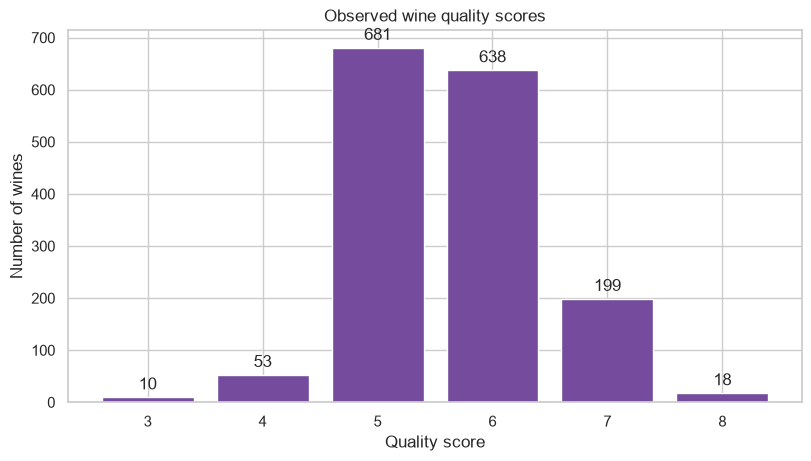

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
bars = ax.bar(quality_counts.index.astype(str), quality_counts.values, color="#754c9d")
ax.bar_label(bars, padding=3)
ax.set(title="Observed wine quality scores", xlabel="Quality score", ylabel="Number of wines")
export_plot(fig, "quality_counts.png")

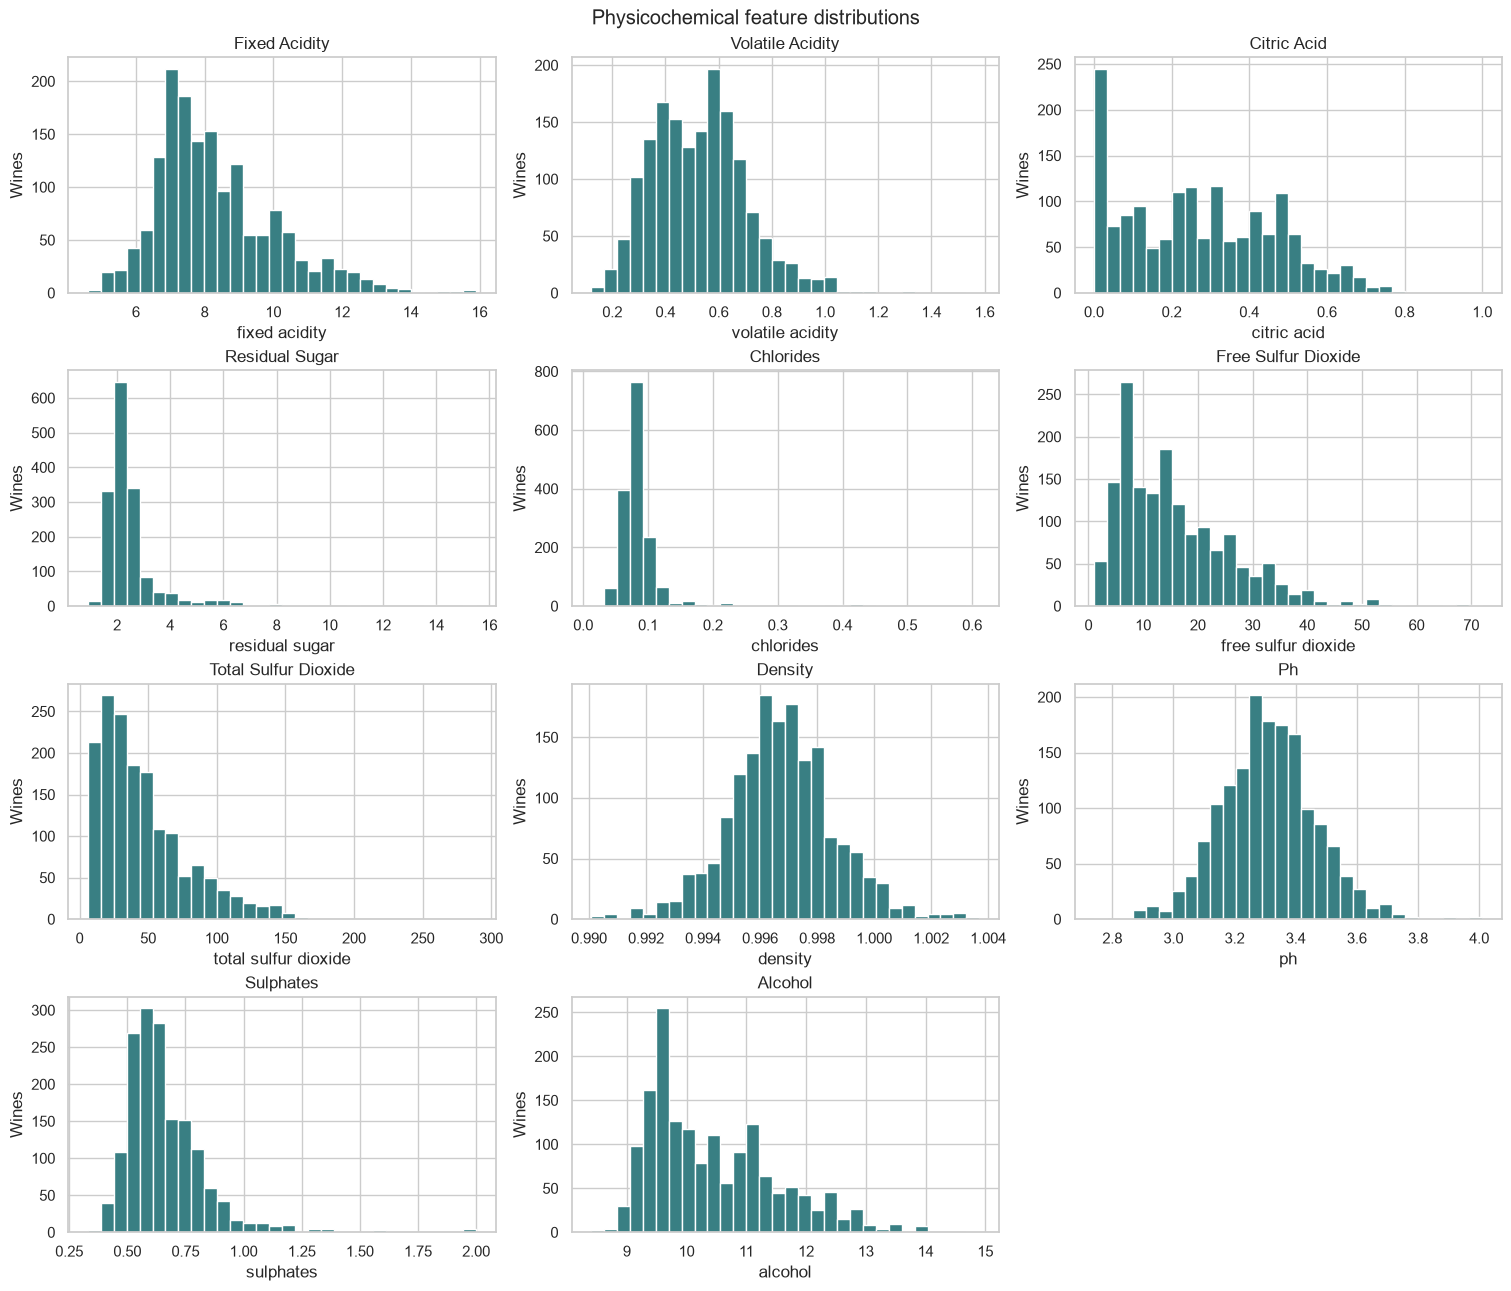

In [5]:
numeric_features = raw.drop(columns=["quality", "wine_type"], errors="ignore").columns.tolist()
ncols = 3
nrows = int(np.ceil(len(numeric_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows), layout="constrained")
for ax, feature in zip(np.ravel(axes), numeric_features):
    ax.hist(raw[feature].dropna(), bins=30, color="#397f83", edgecolor="white")
    ax.set(title=feature.replace("_", " ").title(), xlabel=feature.replace("_", " "), ylabel="Wines")
for ax in np.ravel(axes)[len(numeric_features):]:
    ax.set_visible(False)
fig.suptitle("Physicochemical feature distributions")
export_plot(fig, "feature_distributions.png")

,Spearman correlation with quality
alcohol,0.478532
volatile_acidity,-0.380647
sulphates,0.377060
citric_acid,0.213481
total_sulfur_dioxide,-0.196735
chlorides,-0.189922
density,-0.177074
fixed_acidity,0.114084
free_sulfur_dioxide,-0.056901
ph,-0.043672


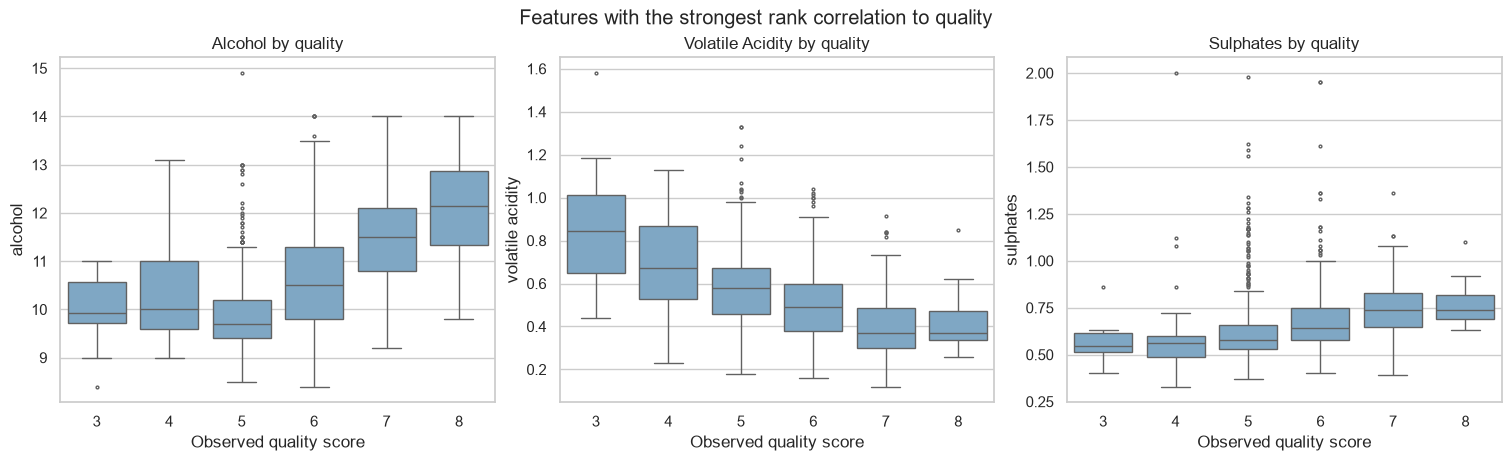

In [6]:
spearman = raw[numeric_features + ["quality"]].corr(method="spearman")["quality"]
feature_correlations = spearman.drop("quality").sort_values(key=lambda s: s.abs(), ascending=False)
display(feature_correlations.rename("Spearman correlation with quality").to_frame())
selected_features = feature_correlations.head(min(3, len(feature_correlations))).index.tolist()
fig, axes = plt.subplots(1, len(selected_features), figsize=(5 * len(selected_features), 4.5),
                         layout="constrained")
for ax, feature in zip(np.atleast_1d(axes), selected_features):
    sns.boxplot(data=raw, x="quality", y=feature, ax=ax, color="#74a9cf", fliersize=2)
    ax.set(title=feature.replace("_", " ").title() + " by quality",
           xlabel="Observed quality score", ylabel=feature.replace("_", " "))
fig.suptitle("Features with the strongest rank correlation to quality")
export_plot(fig, "quality_feature_relationships.png")

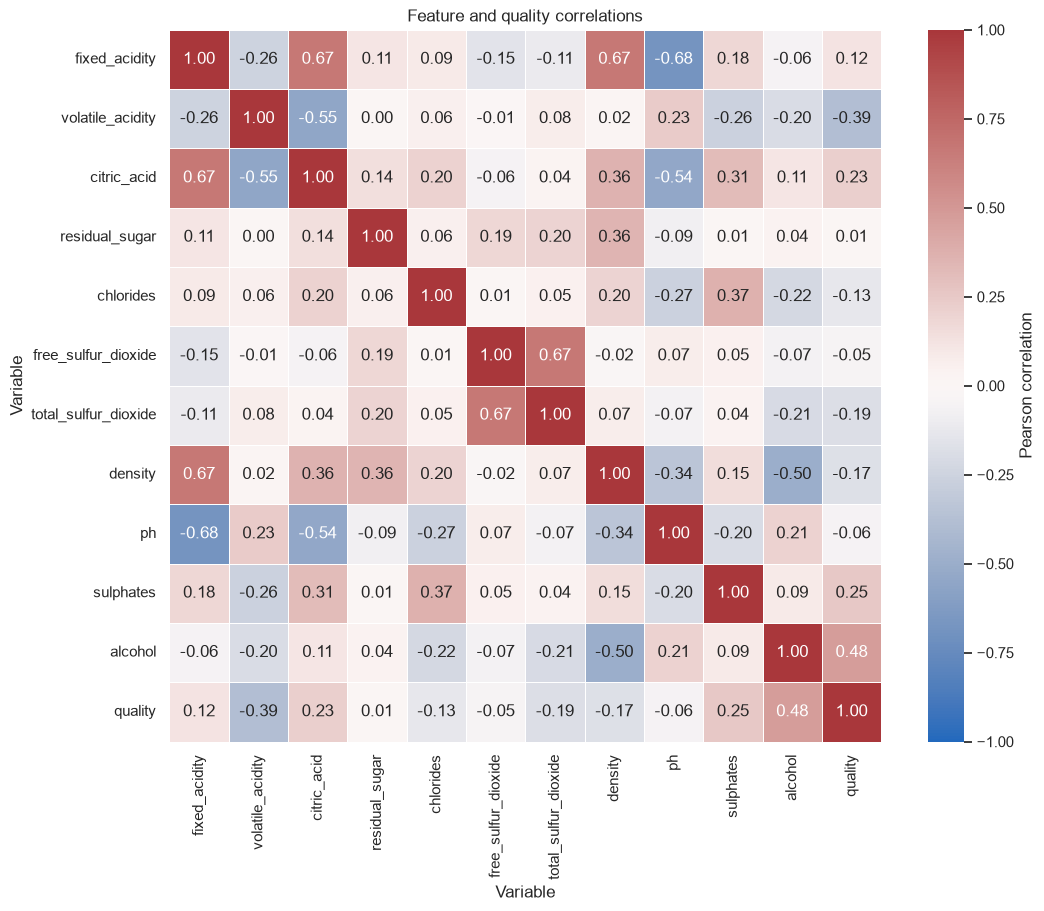

In [7]:
correlations = raw[numeric_features + ["quality"]].corr()
fig, ax = plt.subplots(figsize=(11, 9), layout="constrained")
sns.heatmap(correlations, vmin=-1, vmax=1, center=0, cmap="vlag", annot=True,
            fmt=".2f", square=True, linewidths=0.4, ax=ax,
            cbar_kws={"label": "Pearson correlation"})
ax.set(title="Feature and quality correlations", xlabel="Variable", ylabel="Variable")
export_plot(fig, "feature_correlations.png")

## 4. Data preparation and split

All models use one fixed 80/20 group-aware split, stratified approximately by quality. Grouping on the full input feature row prevents exact copies from appearing in both train and test. The target is separated before fitting any preprocessing. Numeric medians, categorical fill values, one-hot encoding, and optional standardization are learned from training data only.

In [8]:
X = raw.drop(columns="quality")
y = raw["quality"]
observed_classes = np.sort(y.unique())
if len(observed_classes) < 2:
    raise ValueError("Classification needs at least two observed quality classes.")
groups = pd.util.hash_pandas_object(X, index=False).to_numpy()
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
possible_splits = list(splitter.split(X, y, groups))
complete_splits = [
    (train, test) for train, test in possible_splits
    if set(y.iloc[train]) == set(observed_classes)
    and set(y.iloc[test]) == set(observed_classes)
]
if not complete_splits:
    raise ValueError(
        "No 80/20 group-aware split contains every quality class in both partitions. "
        "More examples of the rare classes are needed for per-class evaluation."
    )
train_idx, test_idx = complete_splits[0]
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
assert set(groups[train_idx]).isdisjoint(set(groups[test_idx]))

numeric_columns = X.select_dtypes(include="number").columns.tolist()
categorical_columns = X.select_dtypes(exclude="number").columns.tolist()
def make_preprocessor(standardize=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if standardize:
        numeric_steps.append(("scaler", StandardScaler()))
    transformers = [("numeric", Pipeline(numeric_steps), numeric_columns)]
    if categorical_columns:
        categorical_steps = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ])
        transformers.append(("categorical", categorical_steps, categorical_columns))
    return ColumnTransformer(transformers, remainder="drop")

print(f"Training rows: {len(X_train)}; test rows: {len(X_test)}")
display(pd.DataFrame({
    "train": y_train.value_counts().reindex(observed_classes, fill_value=0),
    "test": y_test.value_counts().reindex(observed_classes, fill_value=0),
}).rename_axis("quality"))

Training rows: 1279; test rows: 320


,train,test
quality,,
3,8,2
4,42,11
5,545,136
6,510,128
7,160,39
8,14,4


## 5. Regression

A random forest regressor predicts a numeric score. MAE and RMSE are in quality-score units; R² compares its squared error with a mean-prediction baseline. Rounding gives a discrete comparison, but it does not turn this into a classifier.

In [9]:
regressor = Pipeline([
    ("preprocess", make_preprocessor()),
    ("model", RandomForestRegressor(
        n_estimators=150, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    )),
])
regressor.fit(X_train, y_train)
regression_predictions = regressor.predict(X_test)
regression_metrics = {
    "MAE": mean_absolute_error(y_test, regression_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test, regression_predictions)),
    "R²": r2_score(y_test, regression_predictions),
}
display(pd.Series(regression_metrics, name="regression test score").to_frame())
rounded_predictions = np.rint(regression_predictions).astype(int)
rounded_accuracy = accuracy_score(y_test, rounded_predictions)
print(f"Exact score after rounding: {rounded_accuracy:.3f}")
display(pd.crosstab(y_test, rounded_predictions, rownames=["Actual quality"],
                    colnames=["Rounded prediction"], dropna=False))

,regression test score
MAE,0.490669
RMSE,0.633712
R²,0.388698


Exact score after rounding: 0.594


Rounded prediction,5,6,7
Actual quality,,,
3,2,0,0
4,6,5,0
5,108,26,2
6,38,73,17
7,1,29,9
8,0,2,2


## 6. Classification

The classifier predicts one of the quality scores observed in training. Macro-F1 gives each class equal weight; weighted-F1 reflects class frequency. The confusion matrix uses observed scores on both axes.

,classification test score
Accuracy,0.603125
Macro-F1,0.295803
Weighted-F1,0.587400


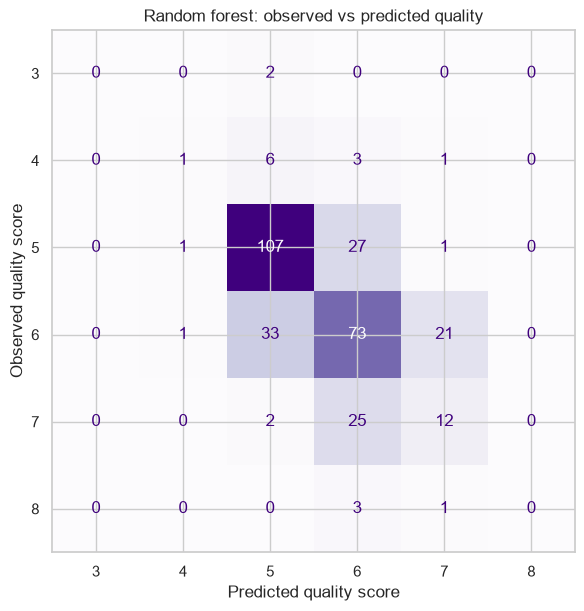

The most common score is 5 (681 of 1599 wines). Minority-class mistakes can be obscured by accuracy and weighted-F1; use macro-F1 and the row counts in the confusion matrix as well.

In [10]:
classifier = Pipeline([
    ("preprocess", make_preprocessor()),
    ("model", RandomForestClassifier(
        n_estimators=150, min_samples_leaf=2, class_weight="balanced_subsample",
        random_state=RANDOM_STATE, n_jobs=-1
    )),
])
classifier.fit(X_train, y_train)
class_predictions = classifier.predict(X_test)
classification_metrics = {
    "Accuracy": accuracy_score(y_test, class_predictions),
    "Macro-F1": f1_score(y_test, class_predictions, average="macro", zero_division=0),
    "Weighted-F1": f1_score(y_test, class_predictions, average="weighted", zero_division=0),
}
display(pd.Series(classification_metrics, name="classification test score").to_frame())
matrix = confusion_matrix(y_test, class_predictions, labels=observed_classes)
fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")
ConfusionMatrixDisplay(matrix, display_labels=observed_classes).plot(
    ax=ax, cmap="Purples", values_format="d", colorbar=False
)
ax.set(title="Random forest: observed vs predicted quality",
       xlabel="Predicted quality score", ylabel="Observed quality score")
export_plot(fig, "classification_confusion_matrix.png")
display(Markdown(
    f"The most common score is {quality_counts.idxmax()} ({quality_counts.max()} of "
    f"{len(raw)} wines). Minority-class mistakes can be obscured by accuracy and weighted-F1; "
    "use macro-F1 and the row counts in the confusion matrix as well."
))

## 7. Does standardization help a distance-based model?

Two 11-neighbor classifiers use the same training and test rows and the same imputation and categorical encoding. The second pipeline standardizes numeric predictors using training statistics. K-nearest neighbors measures distance, so features with larger numerical ranges can dominate without scaling. Tree splits depend on feature order and thresholds, so a monotonic rescaling normally changes a tree much less.

In [11]:
knn_results = {}
for label, standardize in [("Unscaled", False), ("Standardized", True)]:
    model = Pipeline([
        ("preprocess", make_preprocessor(standardize=standardize)),
        ("model", KNeighborsClassifier(n_neighbors=11)),
    ])
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    knn_results[label] = {
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro-F1": f1_score(y_test, predictions, average="macro", zero_division=0),
        "Weighted-F1": f1_score(y_test, predictions, average="weighted", zero_division=0),
    }
scaling_results = pd.DataFrame.from_dict(knn_results, orient="index")
display(scaling_results)
macro_change = scaling_results.loc["Standardized", "Macro-F1"] - scaling_results.loc["Unscaled", "Macro-F1"]
direction = "improved" if macro_change > 0 else "declined" if macro_change < 0 else "did not change"
display(Markdown(
    f"On this test split, standardization {direction} KNN macro-F1 by "
    f"{abs(macro_change):.3f}. This is a comparison of predictive scores, not a "
    "claim that scaling is universally beneficial."
))

,Accuracy,Macro-F1,Weighted-F1
Unscaled,0.471875,0.190263,0.438849
Standardized,0.553125,0.258664,0.535554


On this test split, standardization improved KNN macro-F1 by 0.068. This is a comparison of predictive scores, not a claim that scaling is universally beneficial.

## 8. Class-specific feature importance

For each observed score, the fitted classifier is evaluated as that class versus all others. Permuting one raw input column on the test set measures the drop in **average precision** for that class. This keeps imputation and encoding inside the fitted pipeline and includes wine_type when both variants are loaded. Positive values suggest useful predictive information; values near zero or below zero are uncertain. Correlated predictors can share importance, and importance is not causality.

Quality score vs rest,3,4,5,6,7,8
fixed_acidity,0.071,-0.006,0.009,-0.019,0.006,0.003
volatile_acidity,0.216,0.037,0.014,0.033,-0.002,-0.010
citric_acid,0.124,-0.004,0.003,-0.013,-0.009,0.004
residual_sugar,0.061,-0.009,0.005,0.027,0.006,-0.028
chlorides,-0.008,0.000,0.028,-0.015,-0.053,0.003
free_sulfur_dioxide,-0.035,-0.005,0.008,0.014,-0.038,-0.013
total_sulfur_dioxide,0.038,-0.013,0.054,0.016,-0.015,-0.003
density,-0.083,-0.010,0.009,0.001,-0.000,0.002
ph,0.113,-0.010,0.007,-0.011,-0.023,-0.001
sulphates,0.125,0.027,0.055,0.037,0.052,0.027


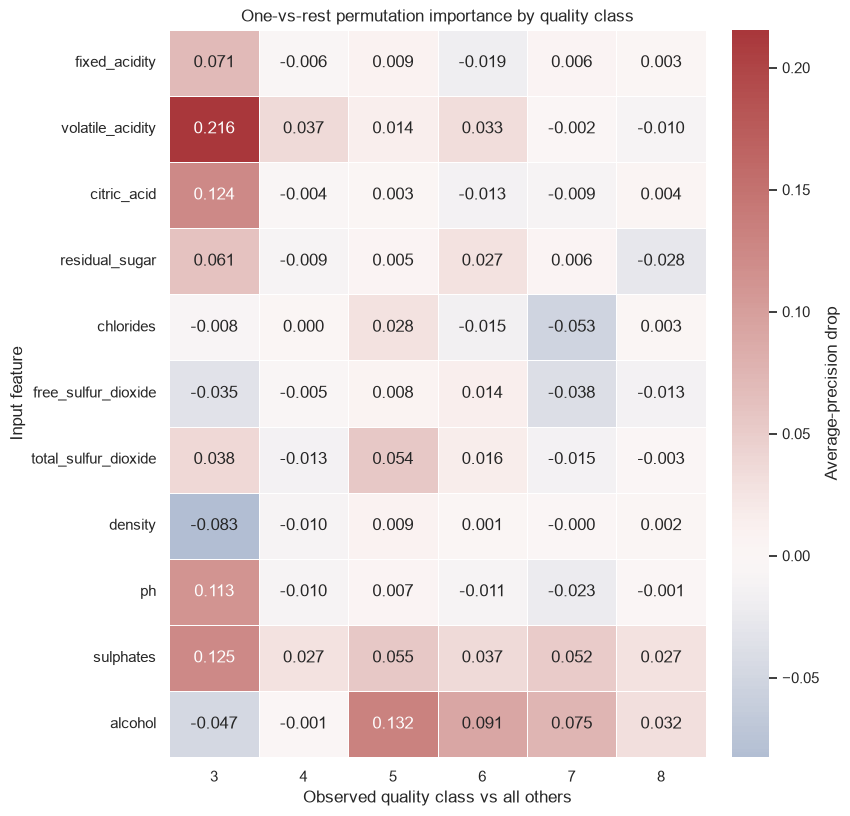

In [12]:
def one_vs_rest_average_precision(estimator, features, labels, positive_class):
    probabilities = estimator.predict_proba(features)
    class_index = np.flatnonzero(estimator.classes_ == positive_class)[0]
    return average_precision_score(
        np.asarray(labels) == positive_class, probabilities[:, class_index]
    )

class_importance = {}
for score in observed_classes:
    result = permutation_importance(
        classifier, X_test, y_test, n_repeats=4, random_state=RANDOM_STATE,
        scoring=partial(one_vs_rest_average_precision, positive_class=score),
        n_jobs=1,
    )
    class_importance[score] = result.importances_mean
importance_table = pd.DataFrame(class_importance, index=X.columns)
importance_table.columns.name = "Quality score vs rest"
display(importance_table.round(3))

fig, ax = plt.subplots(figsize=(max(8, 1.4 * len(observed_classes)), 0.55 * len(X.columns) + 2),
                       layout="constrained")
sns.heatmap(importance_table, annot=True, fmt=".3f", cmap="vlag", center=0,
            linewidths=0.4, cbar_kws={"label": "Average-precision drop"}, ax=ax)
ax.set(title="One-vs-rest permutation importance by quality class",
       xlabel="Observed quality class vs all others", ylabel="Input feature")
export_plot(fig, "class_importance_heatmap.png")

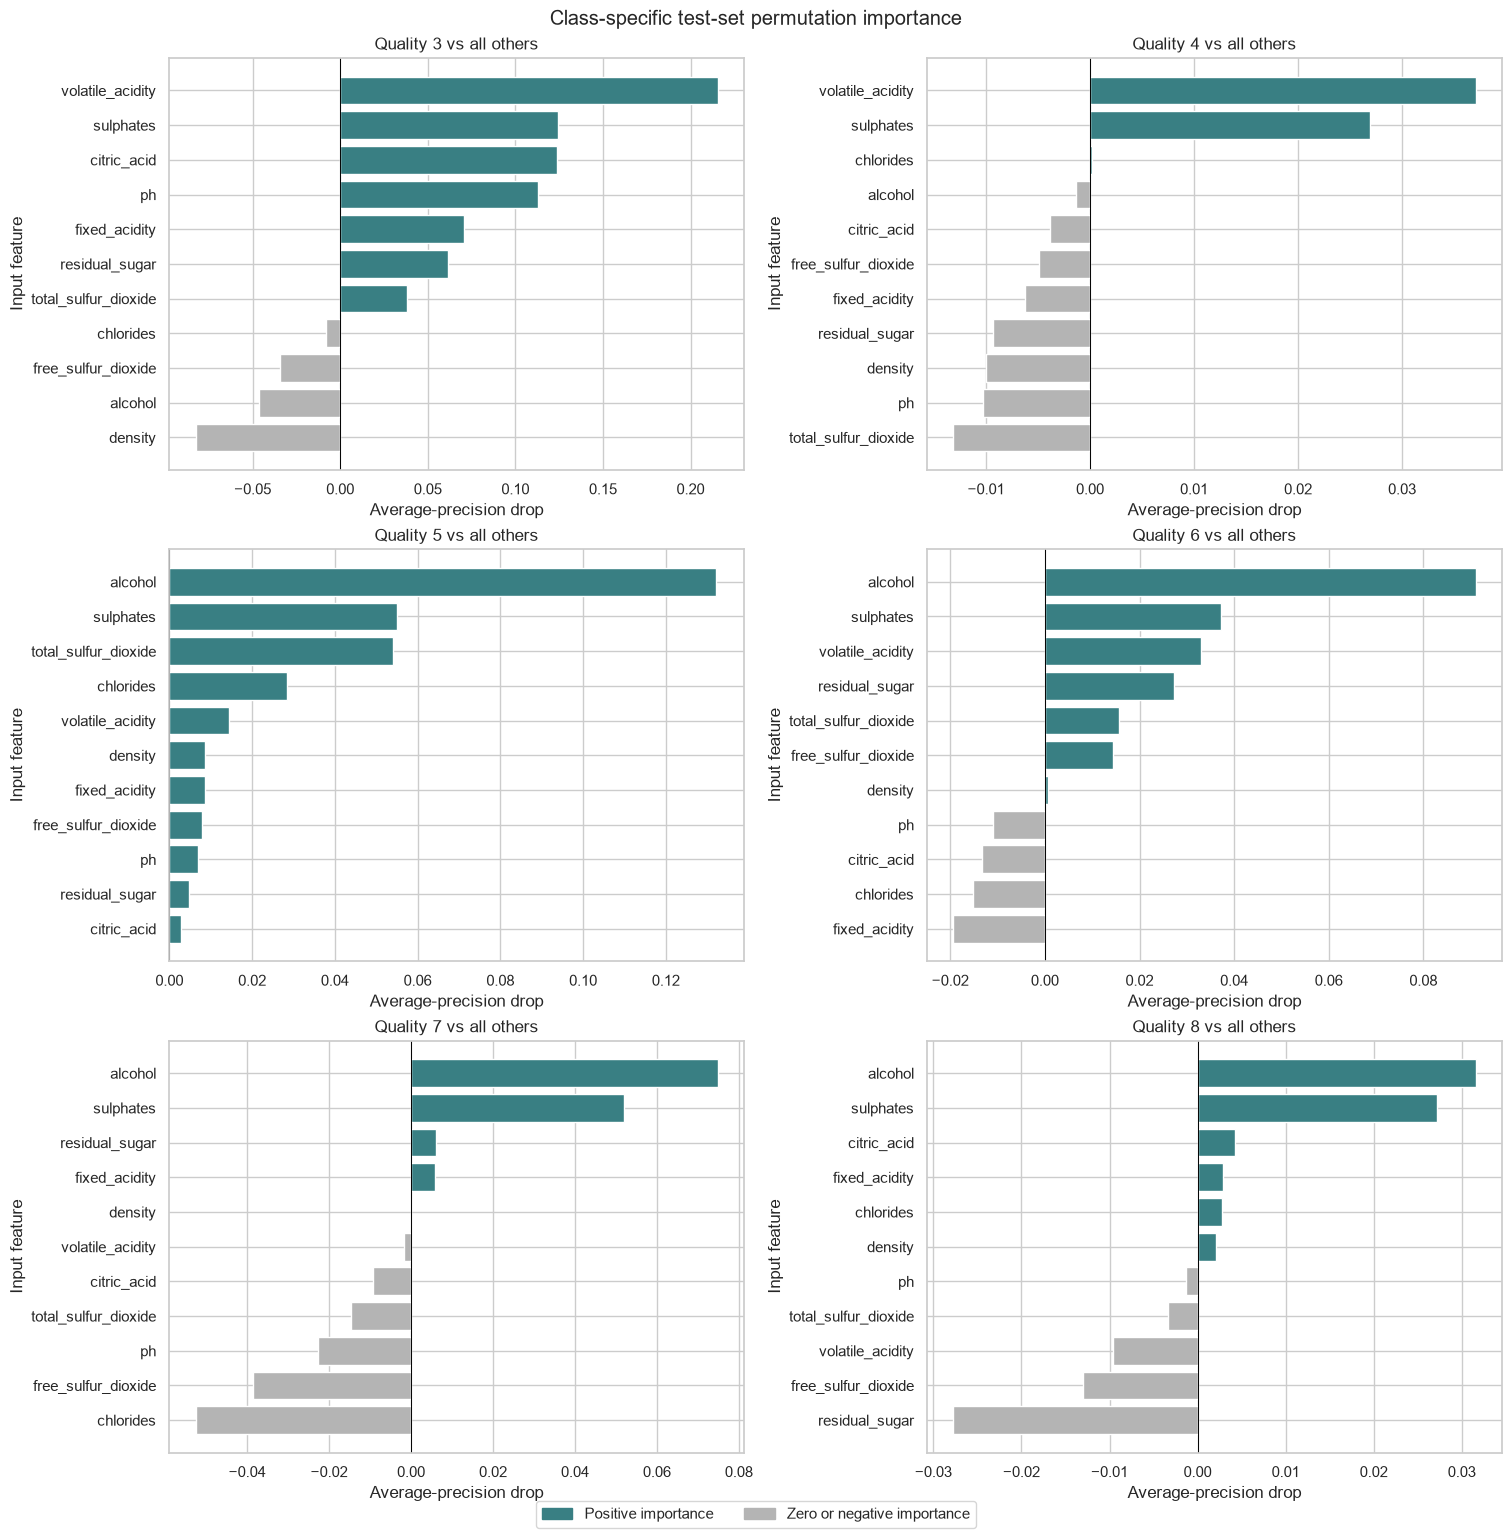

In [13]:
ncols = 2
nrows = int(np.ceil(len(observed_classes) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows), layout="constrained")
for ax, score in zip(np.ravel(axes), observed_classes):
    values = importance_table[score].sort_values()
    ax.barh(values.index, values.values,
            color=np.where(values.values > 0, "#397f83", "#b4b4b4"))
    ax.axvline(0, color="black", linewidth=0.7)
    ax.set(title=f"Quality {score} vs all others", xlabel="Average-precision drop",
           ylabel="Input feature")
for ax in np.ravel(axes)[len(observed_classes):]:
    ax.set_visible(False)
fig.suptitle("Class-specific test-set permutation importance")
fig.legend(handles=[Patch(color="#397f83", label="Positive importance"),
                    Patch(color="#b4b4b4", label="Zero or negative importance")],
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))
export_plot(fig, "class_importance_by_quality.png")

## 9. Findings and limits

The next cell writes the summary from the actual files and fitted models. It contains no stored dataset values or prewritten metrics.

In [14]:
feature_lines = []
for score in observed_classes:
    ranked = importance_table[score].sort_values(ascending=False)
    positive = ranked[ranked > 0].head(2)
    if positive.empty:
        feature_lines.append(f"- Quality {score}: no positive test-set importance was measured.")
    else:
        names = ", ".join(f"{feature} ({value:.3f})" for feature, value in positive.items())
        feature_lines.append(f"- Quality {score}: largest measured importance for {names}.")
variant_label = "variant" if len(found_files) == 1 else "variants"
summary = (
    "### Test-set summary\n\n"
    f"- Data: {len(raw)} wines; {len(found_files)} {variant_label}; "
    f"quality classes {', '.join(map(str, observed_classes))}.\n"
    f"- Regression: MAE {regression_metrics['MAE']:.3f}, "
    f"RMSE {regression_metrics['RMSE']:.3f}, R² {regression_metrics['R²']:.3f}; "
    f"rounded exact-score accuracy {rounded_accuracy:.3f}.\n"
    f"- Classification: accuracy {classification_metrics['Accuracy']:.3f}, "
    f"macro-F1 {classification_metrics['Macro-F1']:.3f}, "
    f"weighted-F1 {classification_metrics['Weighted-F1']:.3f}.\n"
    f"- Scaling: KNN macro-F1 {scaling_results.loc['Unscaled', 'Macro-F1']:.3f} "
    f"unscaled and {scaling_results.loc['Standardized', 'Macro-F1']:.3f} standardized.\n\n"
    "### Predictive feature patterns\n\n" + "\n".join(feature_lines) + "\n\n"
    "The classes are imbalanced, so the aggregate scores do not describe every class equally. "
    "Permutation scores depend on this split and can be unstable for rare classes; correlated "
    "features may divide their importance. These are predictive associations, not causal effects."
)
display(Markdown(summary))

### Test-set summary

- Data: 1599 wines; 1 variant; quality classes 3, 4, 5, 6, 7, 8.
- Regression: MAE 0.491, RMSE 0.634, R² 0.389; rounded exact-score accuracy 0.594.
- Classification: accuracy 0.603, macro-F1 0.296, weighted-F1 0.587.
- Scaling: KNN macro-F1 0.190 unscaled and 0.259 standardized.

### Predictive feature patterns

- Quality 3: largest measured importance for volatile_acidity (0.216), sulphates (0.125).
- Quality 4: largest measured importance for volatile_acidity (0.037), sulphates (0.027).
- Quality 5: largest measured importance for alcohol (0.132), sulphates (0.055).
- Quality 6: largest measured importance for alcohol (0.091), sulphates (0.037).
- Quality 7: largest measured importance for alcohol (0.075), sulphates (0.052).
- Quality 8: largest measured importance for alcohol (0.032), sulphates (0.027).

The classes are imbalanced, so the aggregate scores do not describe every class equally. Permutation scores depend on this split and can be unstable for rare classes; correlated features may divide their importance. These are predictive associations, not causal effects.